In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 0015-91B0

 Directory of C:\Users\DELL_7\Documents\ML

07/21/2026  10:43 AM    <DIR>          .
07/21/2026  10:43 AM    <DIR>          ..
07/21/2026  10:43 AM    <DIR>          .ipynb_checkpoints
07/21/2026  10:42 AM            10,926 9_Social_Network_Ads.csv
07/21/2026  10:43 AM               337 KNN.ipynb
07/21/2026  10:40 AM           116,762 KNN.png
               3 File(s)        128,025 bytes
               3 Dir(s)  138,799,779,840 bytes free


# Read file.

In [4]:
df = pd.read_csv("9_Social_Network_Ads.csv")

In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
df["Purchased"].unique()

array([0, 1])

# Check ofr missing values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [9]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

# Check for outlier and skewness.

In [10]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


# Check relation.

In [13]:
col = df.select_dtypes(exclude="object").columns

In [14]:
df[ col ].corr()

,User ID,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.000721,0.071097,0.007120
Age,-0.000721,1.000000,0.155238,0.622454
EstimatedSalary,0.071097,0.155238,1.000000,0.362083
Purchased,0.007120,0.622454,0.362083,1.000000


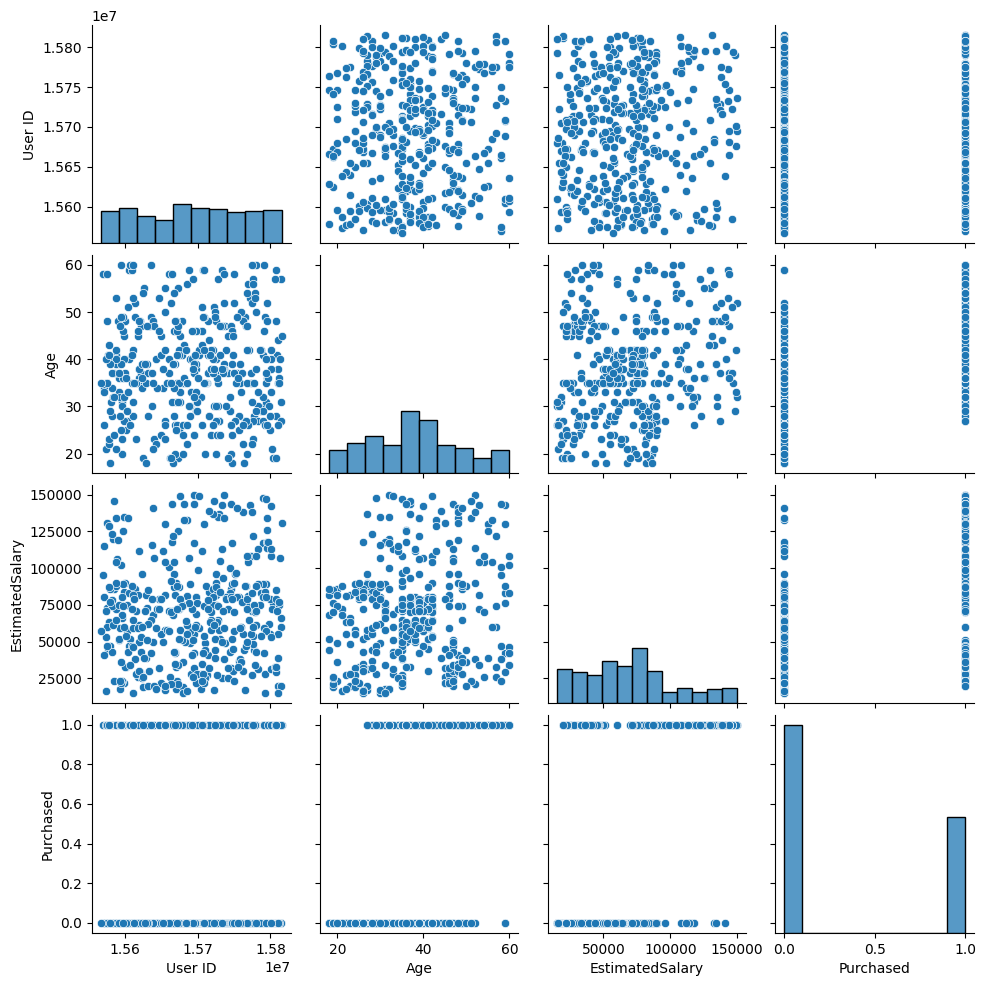

In [15]:
sns.pairplot(df)

# Features and response.

In [16]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [17]:
x = df.iloc[ : ,  2 : 4]
y = df.iloc[ : ,  -1]

# train and test.

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
xtrain, xtest, ytrain, ytest  = train_test_split(x, y,  test_size=0.2,  random_state=1)

# Model preparation.

In [22]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [23]:
knn = KNeighborsClassifier()

knn.fit(xtrain, ytrain)

yp = knn.predict(xtest)

# Model evaluation.

In [24]:
from sklearn.metrics import  accuracy_score,  confusion_matrix, classification_report

In [25]:
asc = accuracy_score(yp, ytest)
cm  = confusion_matrix(yp, ytest)
cr  = classification_report(yp, ytest)

print(asc)
print(cm)
print(cr)

0.75
[[39 11]
 [ 9 21]]
              precision    recall  f1-score   support

           0       0.81      0.78      0.80        50
           1       0.66      0.70      0.68        30

    accuracy                           0.75        80
   macro avg       0.73      0.74      0.74        80
weighted avg       0.75      0.75      0.75        80



# Check of model can imporve or not.

In [26]:
train = knn.score(xtrain, ytrain)
test  = knn.score(xtest, ytest)

print(train, test)

0.8875 0.75


# find the best value of k.

In [31]:
trainsc = []
testsc  = []

for i in range(50, 150):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(xtrain, ytrain)

    tr = knn.score(xtrain, ytrain)
    te = knn.score(xtest, ytest)

    trainsc.append(tr)
    testsc.append(te)
    

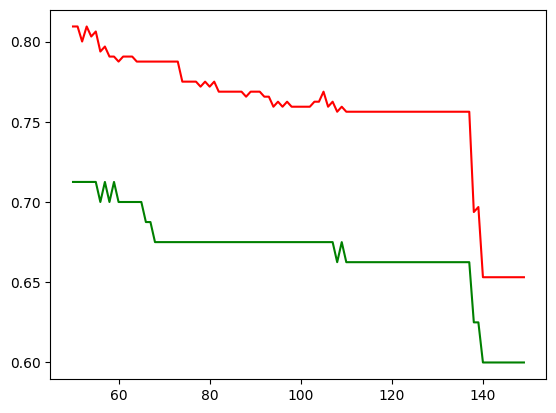

In [32]:
plt.plot( range(50, 150),  trainsc, color="red")
plt.plot( range(50, 150),  testsc,  color="green")
plt.show()

In [34]:
for i in range(125, 150):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(xtrain, ytrain)

    tr = knn.score(xtrain, ytrain)
    te = knn.score(xtest, ytest)

    print(i, tr, te, sep="  ")

125  0.75625  0.6625
126  0.75625  0.6625
127  0.75625  0.6625
128  0.75625  0.6625
129  0.75625  0.6625
130  0.75625  0.6625
131  0.75625  0.6625
132  0.75625  0.6625
133  0.75625  0.6625
134  0.75625  0.6625
135  0.75625  0.6625
136  0.75625  0.6625
137  0.75625  0.6625
138  0.69375  0.625
139  0.696875  0.625
140  0.653125  0.6
141  0.653125  0.6
142  0.653125  0.6
143  0.653125  0.6
144  0.653125  0.6
145  0.653125  0.6
146  0.653125  0.6
147  0.653125  0.6
148  0.653125  0.6
149  0.653125  0.6


# Final model

In [35]:
knn = KNeighborsClassifier(n_neighbors= 140)
knn.fit(xtrain, ytrain)

yp1 = knn.predict(xtest)

# Predition.

In [46]:
age = int(input("Enter age "))
salary = int(input("Enter salary "))

p = knn.predict( [[ age, salary]])[0]

if p == 0:
    print(p)
    print("Person will not purchase")
else:
    print("Person will purchase...")

Enter age  60
Enter salary  2323232


0
Person will not purchase


In [40]:
df[ df[ "Purchased"] == 1]

,User ID,Gender,Age,EstimatedSalary,Purchased
7,15694829,Female,32,150000,1
16,15733883,Male,47,25000,1
17,15617482,Male,45,26000,1
18,15704583,Male,46,28000,1
19,15621083,Female,48,29000,1
...,...,...,...,...,...
393,15635893,Male,60,42000,1
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
